In [1]:
import pandas as pd

In [2]:
import datetime as dt
import yfinance as yf


In [3]:
# Define your date range
start = dt.datetime(2021, 7, 1)
end = dt.datetime(2022, 1, 28)

# Fetch data using yfinance (Note the '.NS' suffix for NSE India stocks)
stk_data = yf.download('TATACONSUM.NS', start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Date,,,,,
2021-07-01,725.378357,729.168124,719.573807,725.138499,1914434
2021-07-02,732.622009,737.611066,722.643955,727.153296,1916135
2021-07-05,735.212585,740.201643,733.965336,739.194251,1020895
2021-07-06,731.662659,737.803046,727.249296,736.843614,1411602
2021-07-07,732.094360,734.972656,720.773078,728.208674,2104914
...,...,...,...,...,...
2022-01-20,694.100891,715.975923,688.104443,698.514254,5297725
2022-01-21,697.075195,712.809901,683.115474,691.750360,4854277


In [5]:
stk_data=stk_data[["Open","High","Low","Close"]]


In [6]:
stk_data

Price,Open,High,Low,Close
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Date,,,,
2021-07-01,725.138499,729.168124,719.573807,725.378357
2021-07-02,727.153296,737.611066,722.643955,732.622009
2021-07-05,739.194251,740.201643,733.965336,735.212585
2021-07-06,736.843614,737.803046,727.249296,731.662659
2021-07-07,728.208674,734.972656,720.773078,732.094360
...,...,...,...,...
2022-01-20,698.514254,715.975923,688.104443,694.100891
2022-01-21,691.750360,712.809901,683.115474,697.075195


In [7]:
column="Close"

In [8]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (144, 1)


In [9]:
len(data1)

144

In [10]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [14]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

# 1. Setup tuning parameters
trends = ['n', 't', 'c', 'ct']
lags = [1, 2, 3, 4]

# 2. Run the Grid Search Loop
for i in lags:
    for td in trends:
        # Train AutoRegressive model
        model = AutoReg(X_train, lags=i, trend=td)
        model_fit = model.fit()
        
        # Generate predictions (y_pred matches your test set length)
        y_pred = model_fit.predict(len(X_train), len(data1) - 1)
        
        print("Lag={}, Trend={}".format(i, td))
        
        # 3. Calculate metrics directly using y_test and y_pred
        rmse = root_mean_squared_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        
        print("RMSE-Testset:", rmse)
        print("MAPE-Testset:", mape)
        print("************")

Lag=1, Trend=n
RMSE-Testset: 0.09722953375277972
MAPE-Testset: 35019731074176.684
************
Lag=1, Trend=t
RMSE-Testset: 0.2759724210392084
MAPE-Testset: 41192912636378.234
************
Lag=1, Trend=c
RMSE-Testset: 0.22262773156740479
MAPE-Testset: 72696502314580.56
************
Lag=1, Trend=ct
RMSE-Testset: 0.1056092901530547
MAPE-Testset: 11390298769112.764
************
Lag=2, Trend=n
RMSE-Testset: 0.09893502223738204
MAPE-Testset: 35678018202812.42
************
Lag=2, Trend=t
RMSE-Testset: 0.30788237846352573
MAPE-Testset: 50185154769725.336
************
Lag=2, Trend=c
RMSE-Testset: 0.20153071184511642
MAPE-Testset: 67715263328360.555
************
Lag=2, Trend=ct
RMSE-Testset: 0.13613138885979176
MAPE-Testset: 57155748155.484146
************
Lag=3, Trend=n
RMSE-Testset: 0.09795448870077703
MAPE-Testset: 34961453941567.04
************
Lag=3, Trend=t
RMSE-Testset: 0.26611236697597457
MAPE-Testset: 38638075933870.24
************
Lag=3, Trend=c
RMSE-Testset: 0.2227706729147681
MAPE-T

In [15]:
len(y_pred)

29

In [18]:
i=1
td='ct'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=root_mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=1,Trend=ct
RMSE-Test: 0.1056092901530547
maPe-Testset: 11390298769112.764
************


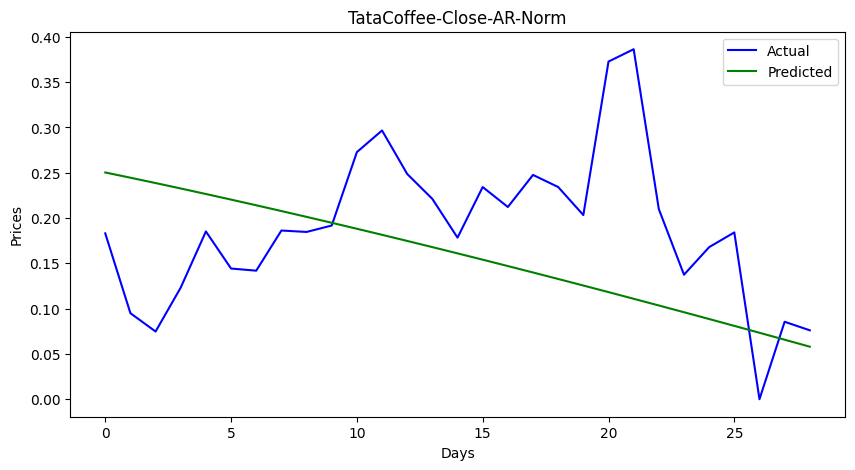

In [19]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [20]:
len(data1)

144

In [21]:
y_test

array([[0.1830575 ],
       [0.09493812],
       [0.07474351],
       [0.12326216],
       [0.18515567],
       [0.14424291],
       [0.1418828 ],
       [0.18620476],
       [0.18463113],
       [0.19171214],
       [0.27275084],
       [0.29661626],
       [0.24862249],
       [0.2210856 ],
       [0.17833694],
       [0.2341982 ],
       [0.21216869],
       [0.2475734 ],
       [0.2341982 ],
       [0.20325144],
       [0.37267213],
       [0.38630994],
       [0.20980824],
       [0.13742451],
       [0.16784639],
       [0.18410692],
       [0.        ],
       [0.08549633],
       [0.0760552 ]])

In [22]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [23]:
aTestNormTable

,Close
0,0.183057
1,0.094938
2,0.074744
3,0.123262
4,0.185156
5,0.144243
6,0.141883
7,0.186205
8,0.184631
9,0.191712


In [24]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [25]:
actual_stock_price_test_ori

array([[696.88323975],
       [680.76483154],
       [677.07092285],
       [685.94573975],
       [697.26702881],
       [689.78344727],
       [689.35174561],
       [697.45892334],
       [697.17108154],
       [698.46630859],
       [713.28955078],
       [717.65490723],
       [708.87609863],
       [703.83917236],
       [696.01977539],
       [706.2376709 ],
       [702.20812988],
       [708.6842041 ],
       [706.2376709 ],
       [700.57702637],
       [731.56671143],
       [734.0612793 ],
       [701.77636719],
       [688.53625488],
       [694.10089111],
       [697.07519531],
       [663.39916992],
       [679.03778076],
       [677.31085205]])

In [26]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [27]:
actual_stock_price_test_oriA

,Close
0,696.88324
1,680.764832
2,677.070923
3,685.94574
4,697.267029
5,689.783447
6,689.351746
7,697.458923
8,697.171082
9,698.466309


In [28]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [29]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

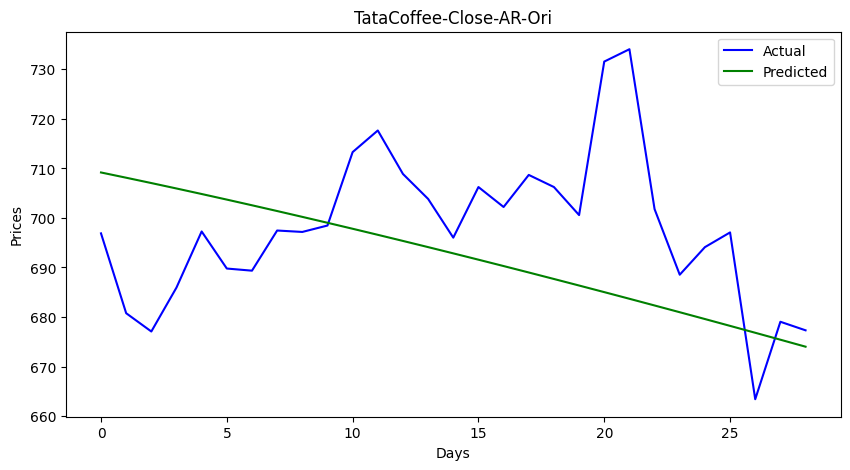

In [30]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [31]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Test: 19.317585446624637
maPe-Testset: 0.022146381386114657


In [32]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [33]:
forecast

array([0.0502353 , 0.04244091, 0.03460319, 0.02672337])

In [34]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [35]:
forecast_stock_price_test_oriF

,Closefore
0,672.587989
1,671.162274
2,669.728632
3,668.287291


In [36]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

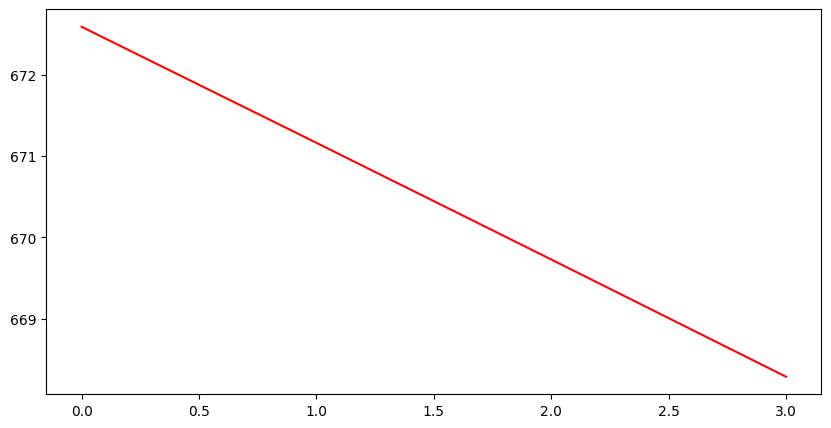

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")